# DSC550 - Project Milestone 1

### Busines Problem: Internet Provider's Customer Churn
#### Unique Spin: Diving deeper into customer segments

Customer churn is a known challenge in many industries, but particularly for internet/cable providers. The market today is highly competitive and customer loyalty is difficult to maintain. Moreover, businesses are aware that retaining existing customers is cheaper than acquiring new ones. We know that predictive models can help identify if a customer is likely to leave for a different provider, but they don't provide any deeper insights into why different segments of customers leave. And a blanket approach for retention can be costly and ineffective for businesses.  

The goal of my project is to dive beyond churn prediction models and instead focus on identifying segments, or groups of customers who share similar characteristics and churn behavior using clustering techniques. I can use features like gender, dependents, contract, monthly charges, etc. Once these clusters are identified, we can analyze churn across clusters and train a churn prediction model using logistic regression or random forest to see if these predictors differ for each group. By uncovering these patterns, my thought is that businesses can develop targeted strategies for customer retention that are more cost-effective, while improving customer satisfaction.  

The business problem being addressed is: “What types of customers are most at risk of churning, and what are the common characteristics of those groups?” This approach goes beyond just providing the predictions but creates actionable insights for the business. The target variable is Churn, and the analysis will start with exploratory data visualization to better understand how customer attributes relate to churn. The clustering step (in the subsequent milestones) will use these insights to define and describe churn segments.

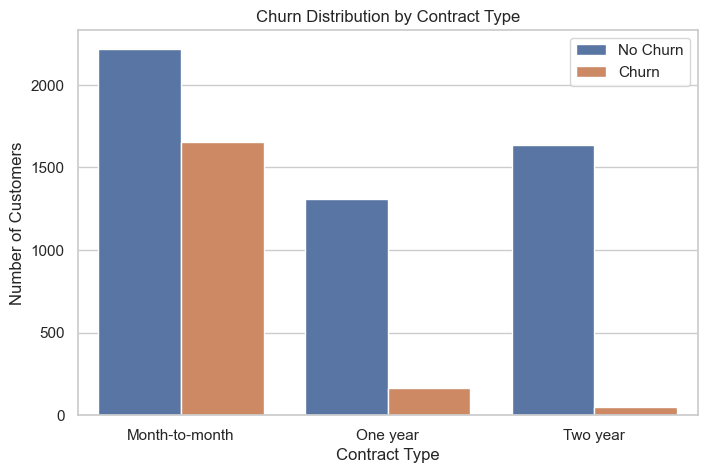

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean TotalCharges column since some are empty strings
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.dropna(subset=["TotalCharges"], inplace=True)

# Convert target column
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Set seaborn plot style
sns.set(style="whitegrid")

# Visualization 1: Churn distribution by contract type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn Distribution by Contract Type")
plt.ylabel("Number of Customers")
plt.xlabel("Contract Type")
plt.legend(["No Churn", "Churn"])
plt.show()


As we might expect to see, month-to-month contract customers have the highest churn count by far. On the other hand, we can see that one year and two year contract customers very seldom churn. This supports the idea that contract flexibility drives churn, and long-term contracts do a better job at retaining customers. One insight we could take away from this is a potential benefit to providing perks or holding promotions for long-term contracts.

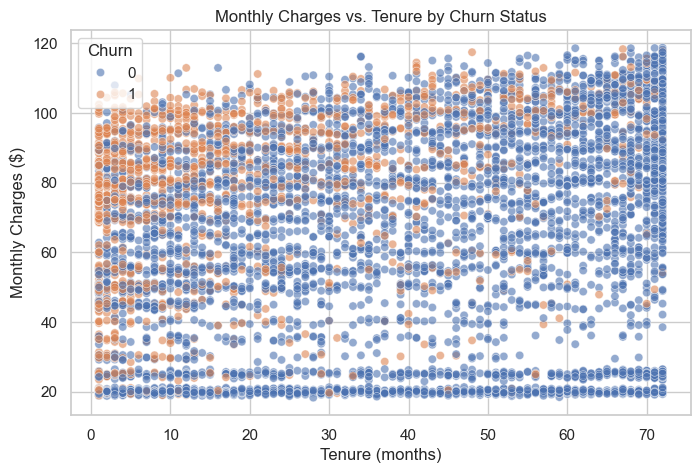

In [3]:
# Visualization 2: Monthly charges vs. tenure scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.6)
plt.title("Monthly Charges vs. Tenure by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges ($)")
plt.show()


In this scatterplot, we can see that customers who churn (shown in orange) are clustered at low tenures, with a range of monthly charges which are more often higher. Non-churn customers appear to have longer tenures even with higher monthly charges. This tells us that high monthly cost coupled with low tenure creates a high churn risk. An important takeaway here would be for the business to consider new customer discounts or incentives for customers with high charges in the first few months.

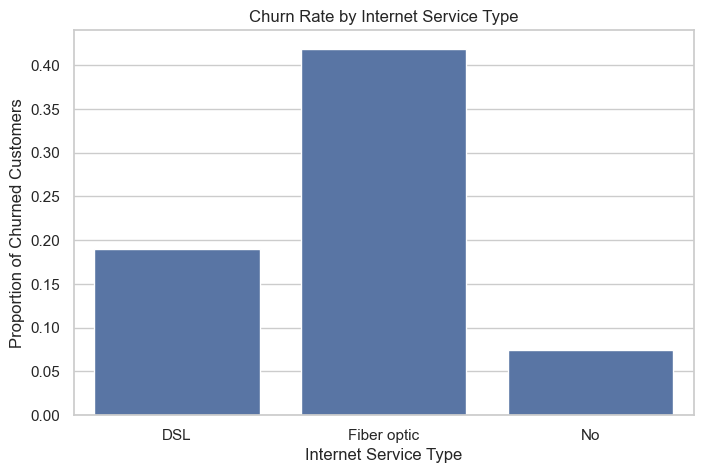

In [5]:
# Visualization 3: Churn rate by Internet Service type
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="InternetService", y="Churn", errorbar=None)
plt.title("Churn Rate by Internet Service Type")
plt.ylabel("Proportion of Churned Customers")
plt.xlabel("Internet Service Type")
plt.show()


When looking at churn rates by internet service types, we can clearly see that fiber optic cusotmers churn at a significantly higher rate than customers with DSL and customers with no internet. It's hard to make any conclusions with this visualization alone, but this tells us more analysis is needed on the fiber optics service with performance, market pricing, and other potential issues. 

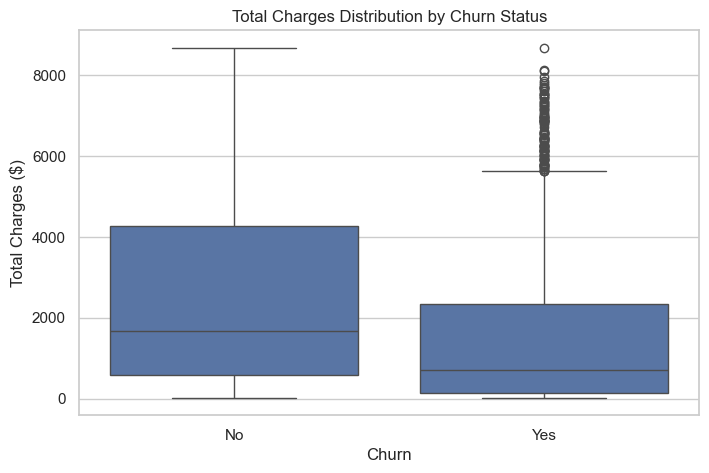

In [7]:
# Visualization 4: Boxplot of Total Charges by Churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges ($)")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

When looking at the total charges distribution by churn, we can see that churned customers tend to have lower total charges, which could be explained by their shorter tenure if they left earlier. There is a wider spread and higher mdeian for customers that did not churn, which indicates they stayed longer and therefore paid more. This visualization supports the insights from the second scatterplot and tells us that we should invest in new customer retention.

The patterns we observed above through the 4 visualizations tells us that churn does not happen randomly and it is very much tied to customer tenure, service type, chargest, etc. These patterns that were identified provide us with a ncie foundation for clustering customers into segments in the subsequent milestones of this project. We can segment our customers based on contract types, pricing, etc. to identify and predict which groups of customers churn, and dig into the why.   

**End of Milestone 1**  

# DSC550 - Project Milestone 2

### Busines Problem: Internet Provider's Customer Churn
#### Unique Spin: Diving deeper into customer segments

In [9]:
#Step 1: Drop any features that are not useful for my model

#Dropping the customer ID column
df.drop(columns=["customerID"], inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Explanation: I decided to drop the customerID column because that feature just served as a unique identifier and would not have provided any predictive value for clustering or churn classification

Step 2: Perform any data extraction/selection steps

Selecting revelant rows or values may be valuable if I want to focus on a specific group. However in this case I determined that no subset filterting was needed because all rows in the dataset represent a valid customer record and is useful for my analysis.

In [11]:
#Step 3: Transform features if necessary

#Categorical features should be binary encoded:
binary_map = {'Yes':1, 'No':0, 'Male':1, 'Female':0}

binary_columns = ['Partner', 'Dependents','PhoneService','PaperlessBilling',
                 'gender']

for col in binary_columns:
    df[col]=df[col].map(binary_map)

#Check results
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [13]:
#Encoding other nomical categorical features (one-hot encoding)

multi_category_columns = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                          'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                         'Contract','PaymentMethod']

df = pd.get_dummies(df, columns=multi_category_columns, drop_first=True)
# Use drop_first=True to eliminate redundancy and avoid multicollinearity

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [15]:
# Ensure all data is numeric
df = df.astype(int)

print(df.dtypes)

gender                                   int32
SeniorCitizen                            int32
Partner                                  int32
Dependents                               int32
tenure                                   int32
PhoneService                             int32
PaperlessBilling                         int32
MonthlyCharges                           int32
TotalCharges                             int32
Churn                                    int32
MultipleLines_No phone service           int32
MultipleLines_Yes                        int32
InternetService_Fiber optic              int32
InternetService_No                       int32
OnlineSecurity_No internet service       int32
OnlineSecurity_Yes                       int32
OnlineBackup_No internet service         int32
OnlineBackup_Yes                         int32
DeviceProtection_No internet service     int32
DeviceProtection_Yes                     int32
TechSupport_No internet service          int32
TechSupport_Y

In [17]:
#Transform some features

from sklearn.preprocessing import StandardScaler

#identify columns to scale
scale_columns = ['MonthlyCharges','TotalCharges','tenure']

scaler = StandardScaler()
df[scale_columns] = scaler.fit_transform(df[scale_columns])
#These columns were standardized to have a mean of 0 and a sd of 1 to ensure that all features
#contribute equally to any clustering we do later

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.280248,0,1,-1.174362,-0.994363,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.064303,1,0,-0.276951,-0.173753,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.239504,1,1,-0.376663,-0.959509,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.512486,0,0,-0.742275,-0.195372,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.239504,1,1,0.188374,-0.940538,1,...,0,0,0,0,0,0,0,0,1,0


In [19]:
#Step 4: Engineer new useful features

#Create one feature that consolidates all the services each customer has

services = ['PhoneService', 'MultipleLines_No phone service', 'OnlineSecurity_No internet service', 
            'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 
            'TechSupport_No internet service', 'StreamingTV_No internet service', 
            'StreamingMovies_No internet service']

df['TotalServicesUsed'] = df[services].apply(lambda row: 8 - sum(row), axis=1)
#sum(row) counts the number of servies the customer doesn't have
#8 is the total number of service columns, so if a customer has 2 no service flags, 8-2 = 6 services

In [50]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServicesUsed
0,0,0,1,0,-1.280248,0,1,-1.174362,-0.994363,0,...,0,0,0,0,0,0,0,1,0,7
1,1,0,0,0,0.064303,1,0,-0.276951,-0.173753,0,...,0,0,0,0,1,0,0,0,1,7
2,1,0,0,0,-1.239504,1,1,-0.376663,-0.959509,1,...,0,0,0,0,0,0,0,0,1,7
3,1,0,0,0,0.512486,0,0,-0.742275,-0.195372,0,...,0,0,0,0,1,0,0,0,0,7
4,0,0,0,0,-1.239504,1,1,0.188374,-0.940538,1,...,0,0,0,0,0,0,0,1,0,7


In [21]:
#Step 5: Deal with missing data (do not just drop rows or columns without justifying this)

print(df.isnull().sum().sort_values(ascending=False).head(10))

gender                                   0
SeniorCitizen                            0
PaymentMethod_Mailed check               0
PaymentMethod_Electronic check           0
PaymentMethod_Credit card (automatic)    0
Contract_Two year                        0
Contract_One year                        0
StreamingMovies_Yes                      0
StreamingMovies_No internet service      0
StreamingTV_Yes                          0
dtype: int64


No missing data in this dataset so nothing to do for this step.

Step 6: Create dummy variables if necessary  

I completed this step in conjuction with step 2 after I did the binary encoding.

Avoiding data snooping

Throughout the steps in milestone 2, I only applied feature-side transformations and never used the target variable of 'churn' for feature engineering or transformations. I will also need to be sure to reapply the scaling after the train/test split in the model building step to make sure data leakage doesn't happen.  

**End of Milestone 2**

# DSC550 - Project Milestone 3

### Busines Problem: Internet Provider's Customer Churn
#### Unique Spin: Diving deeper into customer segments

In this milestone, I will build and evaluate models that will help us identify customer churn segments using clustering and predicting churn likelihood using supervised learning.   
  
First, I will use KMeans clustering because it is efficient aned interpretable, and works well for numeric and scaled data. It will help us semgent customers into loyal and churn-risk clusters.   
We have already scaled Monthly Charges, Total Charges, and Tenure. We have also encoded the categorical features.

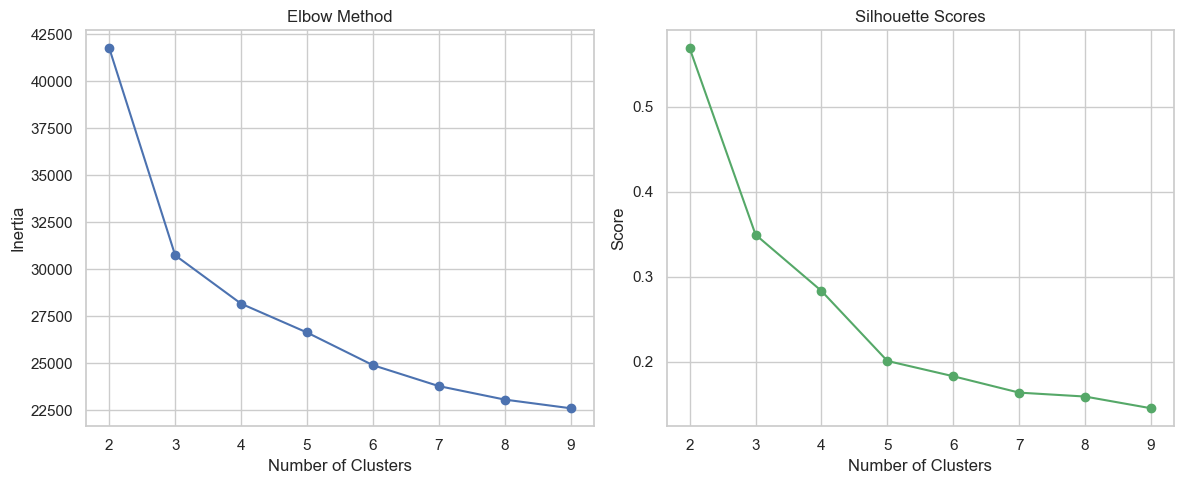

In [23]:
# Using the elbow method and silhouette scores to find the best k

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Try several cluster sizes
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df.drop('Churn', axis=1))
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df.drop('Churn', axis=1), km.labels_))

# Plot elbow and silhouette score
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


I can see a sharp drop from k=2 to k=3, and then a more gradual decline. The highest silhouette score is at k=2 but k=3 still has a silhouette score of around 0.35 which is still solid. So overall, I will use k=3, which will give us three clusters with meaningful differentiation without overfitting.

In [40]:
# Fit KMeans with k=3
k_optimal = 3 
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df['Cluster'] = kmeans.fit_predict(df.drop('Churn', axis=1))

# Churn rate by cluster
churn_by_cluster = df.groupby('Cluster')['Churn'].mean()
print("Churn rate per cluster:\n", churn_by_cluster)

# Cluster size
cluster_size = df['Cluster'].value_counts().sort_index()
print("Cluster size:\n", cluster_size)

#Describle each cluster 
features_to_examine = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServicesUsed']
display(df.groupby('Cluster')[features_to_examine].mean().round(2))

Churn rate per cluster:
 Cluster
0    0.154253
1    0.074342
2    0.433549
Name: Churn, dtype: float64
Cluster size:
 Cluster
0    2269
1    1520
2    3243
Name: count, dtype: int64


,tenure,MonthlyCharges,TotalCharges,Churn,TotalServicesUsed
Cluster,,,,,
0,1.04,0.82,1.27,0.15,7.0
1,-0.07,-1.45,-0.71,0.07,1.0
2,-0.69,0.11,-0.56,0.43,7.0


**Based on the above, we can now describe each cluster.**   
*Cluster 0* are the loyal super users (2,269 customers). The churn rate is low for this group, at 15%, and they are high tenure(1.04), high monthly (0.82) and total charges(1.27), and maxed out the subscribed services (7). These are the high-value, loyal customers that use all services and are willing to pay more. They appear to be satisfied with the provider.  

*Cluster 1* are the low value loyal users (1,520 customers). The churn rate is lowest for this group at 7%. This group has low tenure(almost 0), they have very low monthly (-1.45) and total charges (-0.71). They also use minmal services of just 1. These are minimally engaged and inexpensive customers that likely use a single service and are price sensitive but stable.  

*Cluster 2* are the new and high-risk users (3,243 customers). The churn rate is highest for this group at 43%. The tenure is the lowest (-0.69) and have average monthly (0.11) and low total charges (-0.56). They do also tend to have high number of services used (7). This group appears to subscribe to many services early on, but end up leaving quickly. They are high-risk but could be valuable if they could be retained.

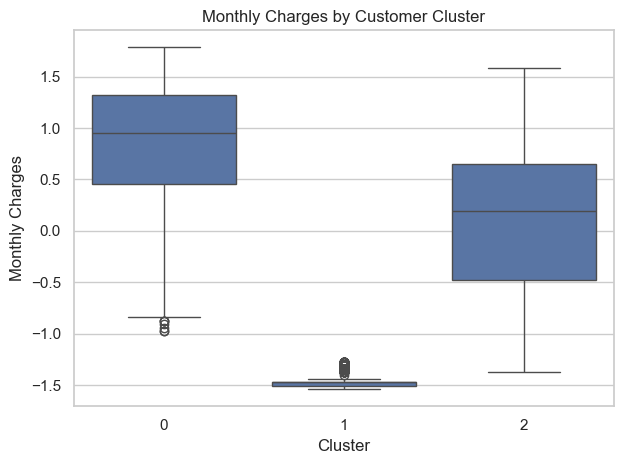

In [33]:
# Code addition for final submission
# Showing key features by clusterto visually show the findings from above.

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df.drop(columns=['Churn']))  # Or use your full feature list


sns.boxplot(data=df, x='Cluster', y='MonthlyCharges')
plt.title('Monthly Charges by Customer Cluster')
plt.xlabel('Cluster')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

Now, I will use Logistic Regression to predict churn. Logistic regression gives us an interpretable baseline and is useful in understanding how the different features relate to churn probability.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Define features and target
features = df.drop(columns=['Churn', 'Cluster'])  # Exclude target and cluster
target = df['Churn']

# Split into training and testing sets
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

# Train logistic regression model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(features_train, target_train)

# Make predictions
target_pred = logreg_model.predict(features_test)
target_prob = logreg_model.predict_proba(features_test)[:, 1]

# Evaluate model
print("Confusion Matrix:")
print(confusion_matrix(target_test, target_pred))

print("\nClassification Report:")
print(classification_report(target_test, target_pred))

print("ROC AUC Score:", roc_auc_score(target_test, target_prob))


Confusion Matrix:
[[1379  170]
 [ 261  300]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1549
           1       0.64      0.53      0.58       561

    accuracy                           0.80      2110
   macro avg       0.74      0.71      0.72      2110
weighted avg       0.79      0.80      0.79      2110

ROC AUC Score: 0.8391256966428804


Confusion Matrix  
  
1379 correctly predicted no churn (true negatives)  
170 predicted churn but didn't (false positives)
261 missed churn (false negatives)
300 correct churn prediction (true positives)  
  
Classification Metrics   
Precision is pretty good at 64% correctly predicted churns. Recall is only 53%, meaning we missed 47% of churners. F1-score gave us 58%, which is a good balance between precision and recall. Finally accuracy is high at 80%, but could be misleading because of imbalance. 

The ROC AUC Score is 0.84 which indicates a strong model that separates the classes well.


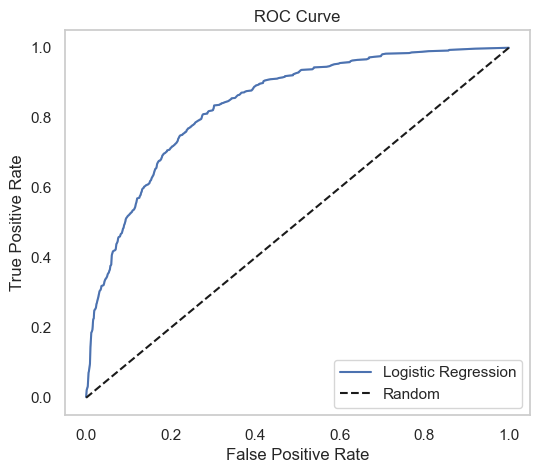

In [56]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(target_test, target_prob)

plt.figure(figsize=(6, 5))
sns.lineplot(x=fpr, y=tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

The ROC curve confirms what we saw earlier with a strong curve higher than the baseline.
The logistic regression model achieved an accuracy of 80% and a strong ROC AUC score of 0.84, showing good predictive power. However, the recall for predicting churners (53%) has room for improvement, especially in identifying customers who are at risk of leaving. This could be addressed in future modeling iterations by using class weighting, trying tree-based models, or maybe adjusting the decision threshold.  

**End of Milestone 3**